# PyTorch Workflow

In [1]:
workflow = {
    1 : "prepare and load",
    2 : "build a model",
    3 : "fitting the model (training)",
    4 : "making predictions and evaluating model (inference)",
    5 : "saving and loading the model",
    6 : "putting it all together"
}

### Import libs

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cu126'

## Data Preparing and Loading

In [3]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting the data into training and testing sets

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Visualize

In [6]:
# Visualize function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot testing data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Check for predictions
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

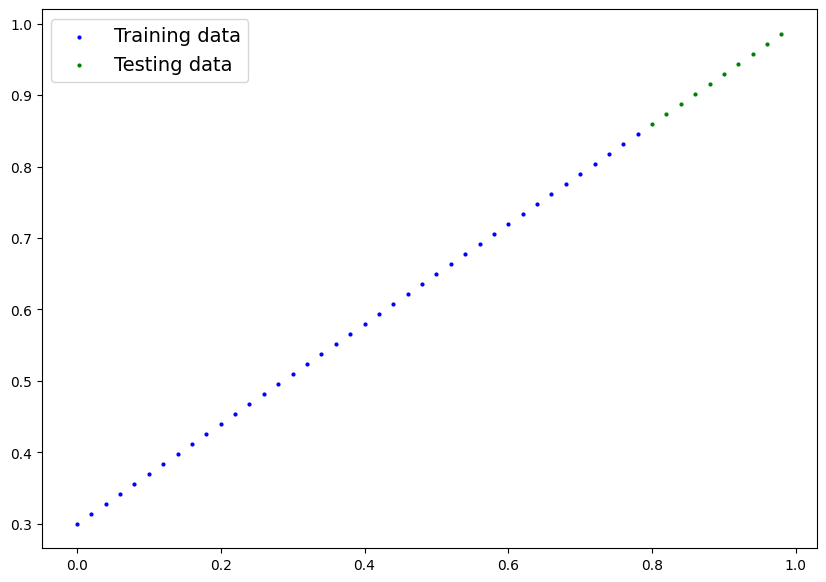

In [7]:
# Display plot figure
plot_predictions()

### Creating a model

In [8]:
from torch import nn

# Create Linear regression model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1,
                                               requires_grad=True,
                                               dtype=torch.float))
        self.bias = nn.Parameter(torch.rand(1,
                                            requires_grad=True,
                                            dtype=torch.float))
        
    # Forward method to define computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

### Checking contents of our PyTorch model

In [9]:
# Create a random seed
torch.manual_seed(42)

# Create a instance of the model
model_0 = LinearRegressionModel()

# List model parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [10]:
# List named dict
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

### Make Predictions

In [11]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

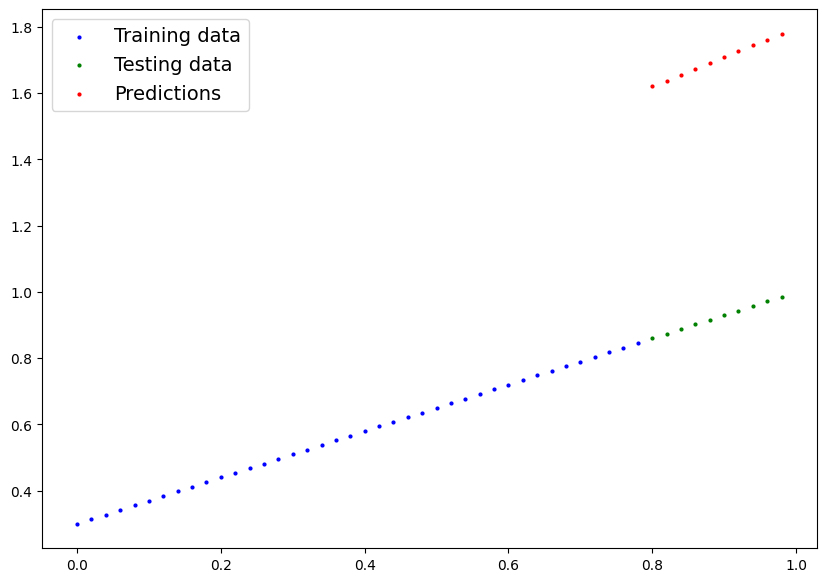

In [12]:
# Display predictions
plot_predictions(predictions=y_preds)

### Things we need to train a model

* **Loss Function:** A function that measure how wrong your model's predictions are to the ideal outputs, lower is better
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters to improve loss

In [13]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [14]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [15]:
# Setup a Loss Function
loss_fn = nn.L1Loss()

# Setup a optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),  # Parameters need to be optimized
                            lr=0.01)    # lr => Learning rate

### Building a training loop (and testing loop)

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves the data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backward through the network to calculate the gradients of each parameters of our model with respect to the loss (**Backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**Gradient descent**)

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [17]:
weight, bias

(0.7, 0.3)

In [18]:
torch.manual_seed(42)

# An epoch is one loop through the data
epochs = 100

# Tracking model performance
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop through the data
for epoch in range(epochs):

    # Set the model to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

    # 1. Forward pass
    y_preds = model_0(X_train)

    # 2. Calculate loss (MAE => Mean Absolute Error)
    loss = loss_fn(y_preds, y_train)
    print(f"Loss: {loss}")

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step()    # by default how the optimizer changes will accumulate through the loop soo... we have to zero them above in step 3 for the next iteration of the loop


    ### Testing
    model_0.eval()  # turns off different settings in the model not needed for evaluation/testing (dropout)
    with torch.inference_mode():    # turns off gradient tracking
        # 1. Forward pass
        test_preds = model_0(X_test)
        
        # 2. Calculate loss
        test_loss = loss_fn(test_preds, y_test)
        
    # Print model evaluations
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

        # Print model parameters
        model_0.state_dict()

Loss: 0.6860889196395874
Epoch: 0 | Loss: 0.6860889196395874 | Test loss: 0.7637526988983154
Loss: 0.6745679974555969
Loss: 0.6630470156669617
Loss: 0.6515260338783264
Loss: 0.6400049924850464
Loss: 0.6284840703010559
Loss: 0.6169630289077759
Loss: 0.6054420471191406
Loss: 0.5939210653305054
Loss: 0.5824000239372253
Loss: 0.5708791017532349
Epoch: 10 | Loss: 0.5708791017532349 | Test loss: 0.6290428042411804
Loss: 0.5593580603599548
Loss: 0.5478371381759644
Loss: 0.5363161563873291
Loss: 0.5247951149940491
Loss: 0.5132741332054138
Loss: 0.5017532110214233
Loss: 0.4902321696281433
Loss: 0.47871121764183044
Loss: 0.4671902060508728
Loss: 0.45566922426223755
Epoch: 20 | Loss: 0.45566922426223755 | Test loss: 0.4943329691886902
Loss: 0.4441482126712799
Loss: 0.43262726068496704
Loss: 0.4211062490940094
Loss: 0.40958523750305176
Loss: 0.3980643153190613
Loss: 0.38654330372810364
Loss: 0.375022292137146
Loss: 0.36350134015083313
Loss: 0.3519803285598755
Loss: 0.34045934677124023
Epoch: 30 | 

In [19]:
import numpy as np
torch.cuda.is_available()

True

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_23060\1766297505.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Train loss")


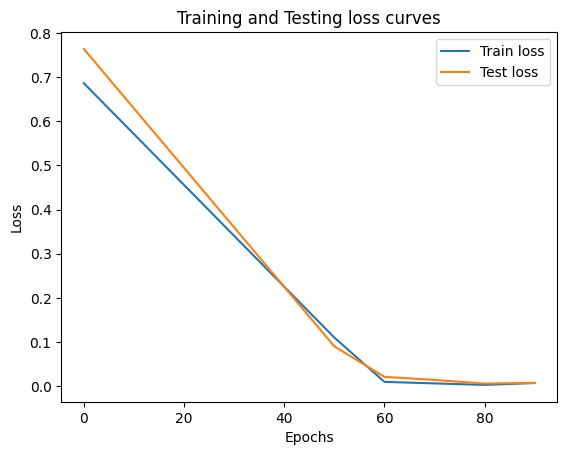

In [20]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [22]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

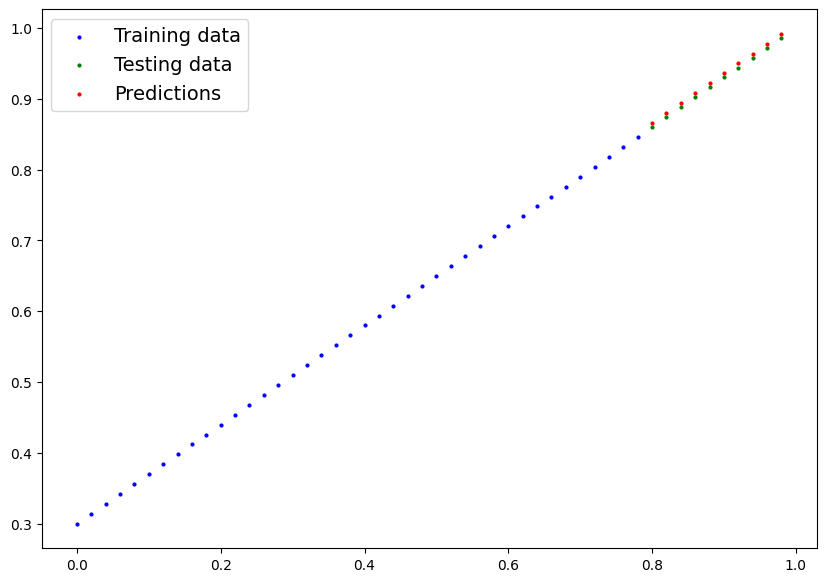

In [23]:
plot_predictions(predictions=y_preds_new)

### Saving model in PyTorch

There are three methods to know for saving and loading models in PyTorch

1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load model's saved state dictionary

In [24]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [41]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save model state dict
print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to : models\01_pytorch_model_0.pth


### Loading model in PyTorch

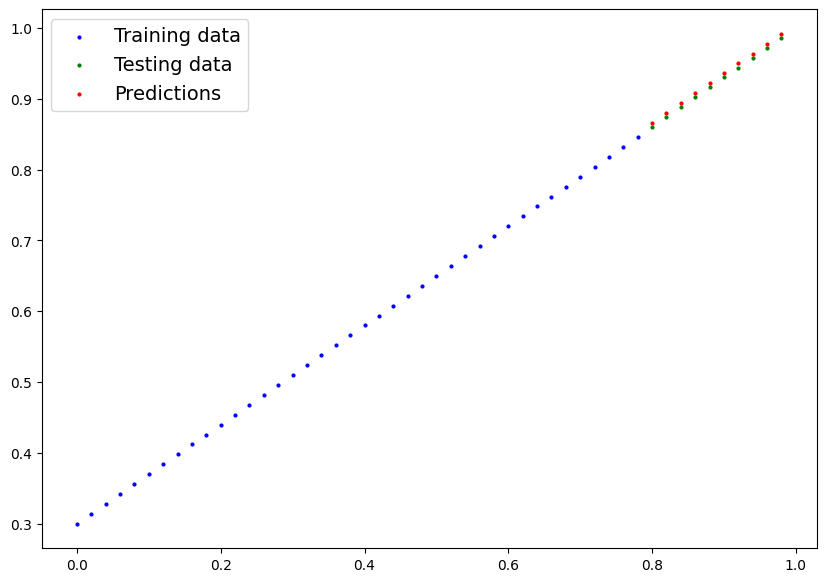

In [ ]:
# 1. Create a instance of the model class
model_loaded = LinearRegressionModel()

# 2. Load the weights into the model
model_loaded.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# 3. Test the model
with torch.inference_mode():
    y_preds_loaded = model_loaded(X_test)

# 4. Plot the predictions
plot_predictions(predictions=y_preds_loaded)

## 6. Putting it all together

In [ ]:
# Import libs
import torch
from torch import nn
import matplotlib.pyplot as plt

In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device using : {device}")

Device using : cuda


### 6.1 Data

In [48]:
# Create some data using linear function y = weight * x + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [51]:
# 1. Splitting data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [52]:
# Visualize function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})

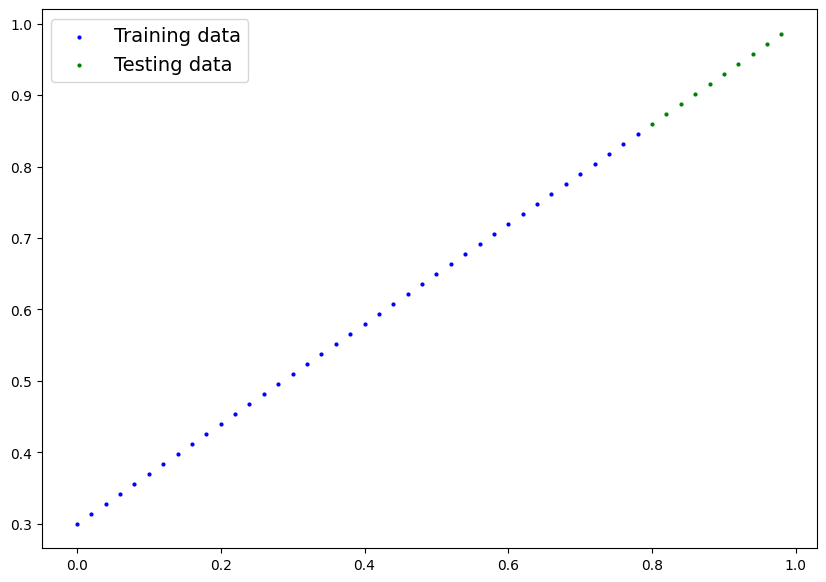

In [53]:
plot_predictions(X_train, y_train, X_test, y_test)

## 6.2 Builing a PyTorch model

In [54]:
# Model class
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        # Use nn.Linear() for creating model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
        
    # Forward function 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# Set manual seed
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

### 6.3 Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [55]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [56]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [57]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.8300], device='cuda:0'))])

In [58]:
# Setup a loss function
loss_fn = nn.L1Loss()  # same as MAE

# Setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [59]:
# Training loop
torch.manual_seed(42)

epochs = 200

# Put data on target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_preds = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_preds, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform Backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing 
    model_1.eval()
    with torch.inference_mode():
        test_preds = model_1(X_test)

        test_loss = loss_fn(test_preds, y_test)

    # Print what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779270172119 | Test loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399681091308594 | Test loss: 0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test loss: 0.16984669864177704
Epoch: 40 | Loss: 0.09433844685554504 | Test loss: 0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test loss: 0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test loss: 0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test loss: 0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test loss: 0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test loss: 0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test loss: 0.01380180101841

### 6.4 Making and evaluating predictions

In [60]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [63]:
# Turn on evaluation mode
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

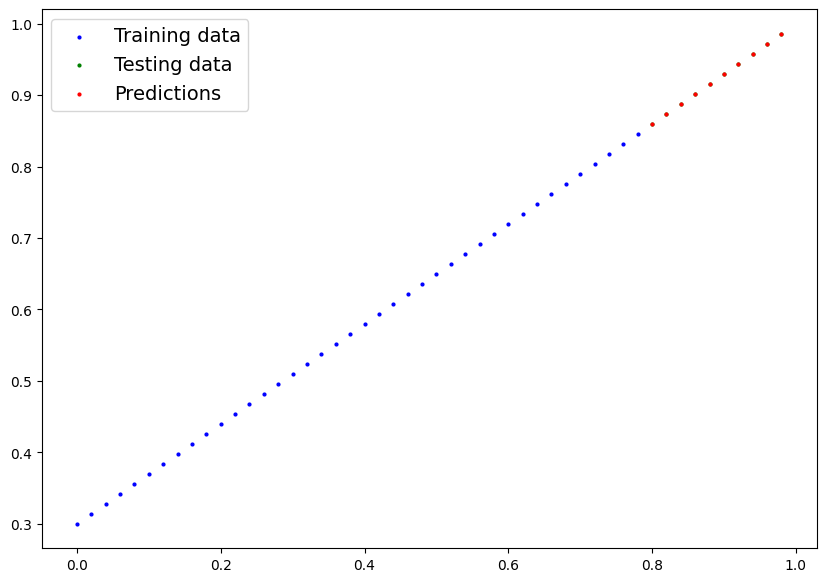

In [64]:
plot_predictions(predictions=y_preds.cpu())

### 6.5 Saving and loading a trainied model

In [66]:
from pathlib import Path

# 1. Create a model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save a model's state dict
print(f"Saving the model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving the model to: models\01_pytorch_model_1.pth


In [67]:
# Load a PyTorch model

# Create a instance of model class
loaded_modelV2 = LinearRegressionModelV2()

# Load a saved model_1 state_dict
loaded_modelV2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Put the loaded model to device
loaded_modelV2.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [68]:
next(loaded_modelV2.parameters()).device

device(type='cuda', index=0)

In [69]:
loaded_modelV2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [70]:
loaded_modelV2.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_modelV2(X_test)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

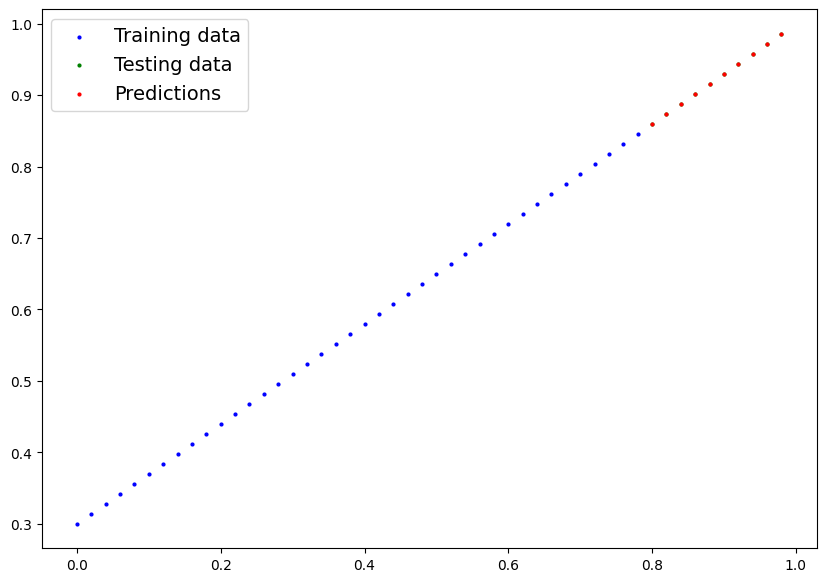

In [72]:
plot_predictions(predictions=loaded_model_preds.cpu())